# Trabalho Prático 2 — Correlação e regressão linear



## 1. Dados e método

O arquivo local contém 934 filhos de 205 famílias. As alturas estão em polegadas:

$$X=\frac{\text{altura do pai}+\text{altura da mãe}}{2}, \qquad Y=\text{altura do filho}.$$

> Observação: o conjunto também traz `midparentHeight`, que aplica a correção histórica $(pai+1{,}08\,mãe)/2$. Ela **não** será usada, porque o enunciado define $X$ como a média simples.

Para uma reta $\hat y=\beta x+\alpha$, mínimos quadrados escolhe $\alpha$ e $\beta$ para minimizar $SSE=\sum_i(y_i-\hat y_i)^2$. A qualidade do ajuste será medida por

$$R^2=1-\frac{SSE}{SST}, \qquad SST=\sum_i(y_i-\bar y)^2.$$

$R^2$ é a fração da variabilidade de $Y$ explicada pela reta; $1-R^2$ é a fração que permanece nos resíduos.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)

candidates = [Path('GaltonFamilies.csv'), Path('Trabalho Prático 2/GaltonFamilies.csv')]
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('GaltonFamilies.csv não encontrado.')

df = pd.read_csv(data_path, dtype={'family': 'string'})
df = df.drop(columns=['rownames'], errors='ignore')
df['parentAverage'] = (df['father'] + df['mother']) / 2

print(f'{len(df)} observações, {df.family.nunique()} famílias')
display(df.head())
display(df[['father', 'mother', 'parentAverage', 'childHeight']].describe().T)
print('Valores ausentes nas variáveis da análise:',
      df[['parentAverage', 'childHeight', 'gender']].isna().sum().sum())

934 observações, 205 famílias


,family,father,mother,midparentHeight,children,childNum,gender,childHeight,parentAverage
0,1,78.5,67.0,75.43,4,1,male,73.2,72.75
1,1,78.5,67.0,75.43,4,2,female,69.2,72.75
2,1,78.5,67.0,75.43,4,3,female,69.0,72.75
3,1,78.5,67.0,75.43,4,4,female,69.0,72.75
4,2,75.5,66.5,73.66,4,1,male,73.5,71.00


,count,mean,std,min,25%,50%,75%,max
father,934.0,69.1971,2.4765,62.0,68.0,69.00,71.000,78.50
mother,934.0,64.0893,2.2909,58.0,63.0,64.00,65.875,70.50
parentAverage,934.0,66.6432,1.7368,62.0,65.5,66.75,67.500,72.75
childHeight,934.0,66.7459,3.5793,56.0,64.0,66.50,69.700,79.00


Valores ausentes nas variáveis da análise: 0


## 2. Tarefa 1 — análise estratificada por gênero

Separação dos dois subconjuntos pedidos. Depois ajustamos uma reta em cada grupo. A função abaixo também calcula $SSE$, $SST$, erro quadrático médio (MSE) e $R^2$.

In [14]:
df_male = df.loc[df['gender'].eq('male')].copy()
df_female = df.loc[df['gender'].eq('female')].copy()

print(f'Meninos: {len(df_male)} observações')
print(f'Meninas:  {len(df_female)} observações')

Meninos: 481 observações
Meninas:  453 observações


In [15]:
def fit_group(data, label):
    X = data[['parentAverage']]
    y = data['childHeight']
    model = LinearRegression().fit(X, y)
    prediction = model.predict(X)
    residual = y.to_numpy() - prediction
    sse = np.sum(residual**2)
    sst = np.sum((y - y.mean())**2)
    return model, {
        'grupo': label, 'n': len(data),
        'alpha': model.intercept_, 'beta': model.coef_[0],
        'r': data['parentAverage'].corr(y),
        'R²': r2_score(y, prediction),
        'SSE': sse, 'SST': sst,
        'MSE': mean_squared_error(y, prediction),
        'variância residual (%)': 100 * sse / sst
    }

model_all, result_all = fit_group(df, 'Todos')
model_male, result_male = fit_group(df_male, 'Meninos')
model_female, result_female = fit_group(df_female, 'Meninas')

results = pd.DataFrame([result_all, result_male, result_female]).set_index('grupo')
display(results)

for group, row in results.iterrows():
    print(f"{group:8s}: ŷ = {row['beta']:.4f}x + {row['alpha']:.4f}; "
          f"R² = {row['R²']:.4f}")

,n,alpha,beta,r,R²,SSE,SST,MSE,variância residual (%)
grupo,,,,,,,,,
Todos,934,22.4618,0.6645,0.3224,0.1040,10709.9860,11952.6995,11.4668,89.6031
Meninos,481,19.5767,0.7458,0.4849,0.2351,2527.6568,3304.7408,5.2550,76.4858
Meninas,453,18.3093,0.6865,0.5155,0.2657,1841.7873,2508.1928,4.0658,73.4308


Todos   : ŷ = 0.6645x + 22.4618; R² = 0.1040
Meninos : ŷ = 0.7458x + 19.5767; R² = 0.2351
Meninas : ŷ = 0.6865x + 18.3093; R² = 0.2657


C:\Users\adria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\adria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


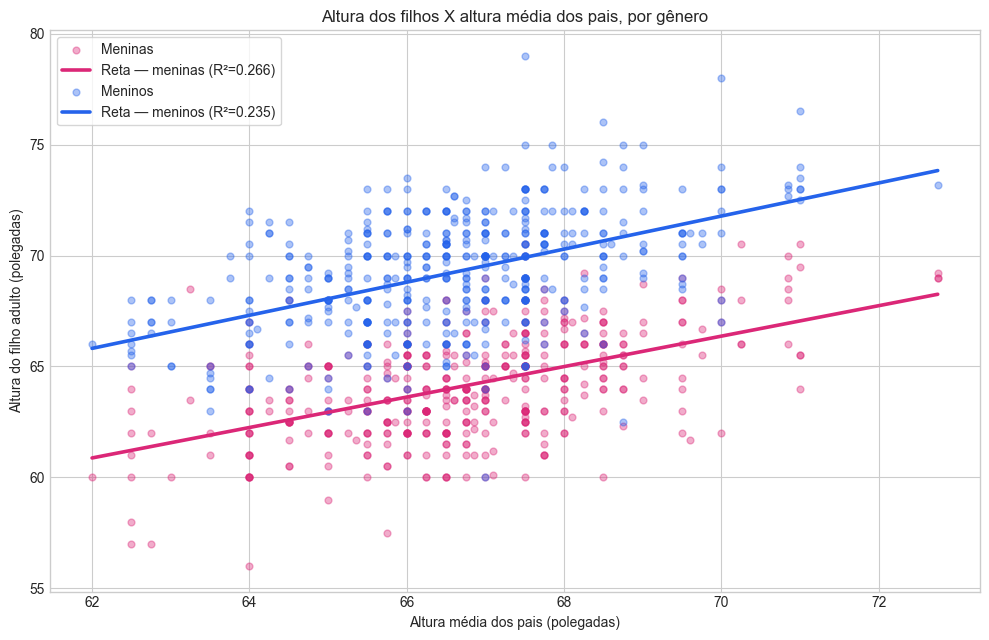

In [18]:
colors = {'male': '#2563eb', 'female': '#db2777'}
labels = {'male': 'Meninos', 'female': 'Meninas'}
models = {'male': model_male, 'female': model_female}

fig, ax = plt.subplots(figsize=(10, 6.5))
for gender, group in df.groupby('gender'):
    ax.scatter(group['parentAverage'], group['childHeight'],
               s=24, alpha=0.38, color=colors[gender], label=labels[gender])
    x_line = np.linspace(group['parentAverage'].min(), group['parentAverage'].max(), 200)
    y_line = models[gender].predict(x_line.reshape(-1, 1))
    r2 = results.loc[labels[gender], 'R²']
    ax.plot(x_line, y_line, color=colors[gender], linewidth=2.6,
            label=f'Reta — {labels[gender].lower()} (R²={r2:.3f})')

ax.set(title='Altura dos filhos X altura média dos pais, por gênero',
       xlabel='Altura média dos pais (polegadas)',
       ylabel='Altura do filho adulto (polegadas)')
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

### Comparação dos resultados

No conjunto agregado, a reta é aproximadamente $\hat y=0{,}6645x+22{,}4618$ e $R^2=0{,}1040$, confirmando o valor de 0,10 informado no enunciado. Separando os grupos:

- **meninos:** $\hat y=0{,}7458x+19{,}5767$ e $R^2=0{,}2351$;
- **meninas:** $\hat y=0{,}6865x+18{,}3093$ e $R^2=0{,}2657$.

Quando meninos e meninas são analisados separadamente, o modelo explica melhor a altura dos filhos. Mesmo assim, a altura dos pais não determina completamente a altura adulta, pois fatores como genética, alimentação, saúde e ambiente também influenciam.

Essa melhora acontece porque meninos e meninas têm alturas médias diferentes: aproximadamente 69,23 polegadas para meninos e 64,10 para meninas. Quando o gênero não é considerado, essa diferença acaba sendo tratada pelo modelo como erro.

## 3. Tarefa 2 — variáveis de confusão e paradoxos

### 3.1 O gênero como variável omitida (e a ressalva sobre “confusão”)

O gênero influencia a altura dos filhos, pois meninos e meninas possuem alturas médias diferentes. Quando essa variável não é considerada, o modelo mistura as diferenças entre os gêneros com as variações existentes dentro de cada grupo. Isso aumenta o erro do modelo e reduz sua capacidade de explicar os dados.

Nesse exercício, o gênero pode ser tratado como uma variável de confusão. Porém ele é uma variável importante que foi deixada de fora do modelo. Para ser considerado um confundidor, o gênero também precisaria estar claramente relacionado à altura média dos pais, o que não acontece de forma significativa nesses dados. Além disso, essa análise mostra apenas associações e não comprova relações de causa e efeito.

In [17]:
group_summary = (df.groupby('gender')
                   .agg(n=('childHeight', 'size'),
                        media_X=('parentAverage', 'mean'),
                        dp_X=('parentAverage', 'std'),
                        media_Y=('childHeight', 'mean'),
                        dp_Y=('childHeight', 'std')))
display(group_summary)
print('Diferença absoluta entre as médias de X:',
      f"{group_summary['media_X'].max() - group_summary['media_X'].min():.3f} polegada")

,n,media_X,dp_X,media_Y,dp_Y
gender,,,,,
female,453,66.7045,1.7686,64.1040,2.3557
male,481,66.5854,1.7061,69.2341,2.6239


Diferença absoluta entre as médias de X: 0.119 polegada


### 3.2 Agrupamento heterogêneo

A correlação mostra como duas variáveis se relacionam em torno de suas médias. Como meninos e meninas possuem alturas médias diferentes, analisar todos juntos com uma única média e uma única reta representa mal os dois grupos. Isso gera erros maiores e sistemáticos.

Ao separar os dados por gênero, parte da variação que antes era considerada erro passa a ser explicada pelo grupo. Por isso, o R²
 aumenta. Esse resultado mostra que uma correlação geral deve ser analisada com cuidado quando existem subgrupos importantes.

Entretanto, separar os dados em muitos grupos pequenos pode gerar resultados pouco confiáveis. Para comparar corretamente as retas de meninos e meninas, seria necessário usar um modelo que incluísse o gênero e sua interação com a altura média dos pais.

Também é importante considerar que irmãos não são observações totalmente independentes, pois compartilham os mesmos pais, parte da genética e do ambiente. As retas ainda podem ser usadas para descrever os dados, mas análises estatísticas mais rigorosas devem considerar o agrupamento por família.

### 3.3 Paradoxo de Simpson

O Paradoxo de Simpson acontece quando uma relação observada separadamente nos grupos diminui, desaparece ou muda de direção quando todos os dados são analisados juntos. Isso pode ocorrer por causa de uma terceira variável que influencia os grupos e as variáveis analisadas.

Por exemplo, imagine duas regiões com condições de nutrição diferentes. Na região A, os filhos possuem melhor nutrição e são mais altos, embora seus pais sejam, em média, mais baixos. Na região B, os filhos possuem pior nutrição e são mais baixos, apesar de seus pais serem mais altos.

Dentro de cada região, filhos de pais mais altos ainda poderiam apresentar maior altura. Entretanto, ao juntar os dados, a relação poderia parecer muito fraca ou até negativa. Nesse caso, a região e as condições de nutrição estariam interferindo no resultado.

Neste trabalho, separar meninos e meninas melhora a capacidade explicativa do modelo. Porém, não ocorre um Paradoxo de Simpson completo, pois a relação entre a altura dos pais e a dos filhos continua positiva em todas as análises. O que ocorre é uma perda de qualidade do modelo causada pela mistura de grupos com características diferentes.


## 4. Conclusão

A regressão agregada explica somente 10,4% da variância da altura dos filhos. Controlar a heterogeneidade por gênero eleva o valor para 23,5% nos meninos e 26,6% nas meninas, porque remove dos resíduos a diferença sistemática de nível entre os grupos. Mesmo estratificado, o modelo conserva grande variância residual e não autoriza afirmações causais. A principal lição é que correlação e $R^2$ dependem da população analisada: misturar subpopulações pode ocultar relações internas e, em condições mais extremas, produzir o Paradoxo de Simpson.